# Color-based Nearest Neighbors Image Retrieval (Pattern Matching)

Metode: Dominant Intensity

Sample case: Deteksi nominal uang kertas

# 0. Data path

In [ ]:
path_referensi = "/content/drive/MyDrive/uang/referensi"
path_uji = "/content/drive/MyDrive/uang/pengujian"

# 1. Load Citra Referensi

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

file_referensi = os.listdir(path_referensi)
print(file_referensi)

['20-Depan.jpeg', '20-belakang.jpeg', '10-depan.jpeg', '1-belakang.jpeg', '5-depan.jpeg', '5-belakang.jpeg', '10-belakang.jpeg', '1-depan.jpeg']


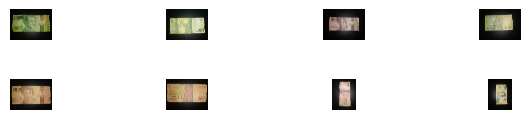

In [ ]:
import matplotlib.pyplot as plt
# Menampilkan semua 28 gambar dalam grid 7x4
num_cols = 4  # Jumlah kolom
num_rows = 7  # Jumlah baris

for i in range(len(file_referensi)):  # Loop melalui semua file referensi
  plt.subplot(num_rows, num_cols, i+1)  # Sesuaikan subplot menjadi 7x4
  img_path = os.path.join(path_referensi, file_referensi[i])
  plt.imshow(plt.imread(img_path))
  plt.tight_layout()
  plt.axis('off')

plt.show()

# 2. Ekstraksi fitur untuk citra referensi

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def create_features(img):
  R = np.mean(img[:,:,0].flatten())
  G = np.mean(img[:,:,1].flatten())
  B = np.mean(img[:,:,2].flatten())
  img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
  H = np.mean(img_hsv[0])
  return [R,G,B,H]

In [ ]:
feat_referensi = []
for file_img in file_referensi:
  # Gunakan os.path.join untuk menggabungkan path
  img_path = os.path.join(path_referensi, file_img)
  img = plt.imread(img_path)
  feat_referensi.append(create_features(img))

print(feat_referensi)

[[61.85929036458333, 69.15567138671875, 39.933946940104164, 52.67239583333333], [88.23172444661458, 94.13785400390626, 70.83925699869792, 56.825520833333336], [55.053339029947914, 49.140062662760414, 46.630137532552084, 39.756510416666664], [64.26153401692709, 64.4673095703125, 49.861378580729166, 38.868229166666666], [97.05834065755208, 77.72875813802084, 56.11501383463542, 36.72213541666667], [105.58259847005208, 88.26916015625, 64.40602132161459, 36.44765625], [88.22470540364583, 77.64858479817708, 72.96994059244791, 37.78819444444444], [57.806943359375, 56.7056298828125, 44.79421223958333, 56.98020833333333]]


# 3. Load citra yang akan dideteksi

In [ ]:
file_uji = os.listdir(path_uji)
print(file_uji)

['uji-20-depan.jpeg', 'uji-20-belakang.jpeg', 'uji-10-depan.jpeg', 'uji-10-belakang.jpeg', 'uji-5-depan.jpeg', 'uji-5-belakang.jpeg']


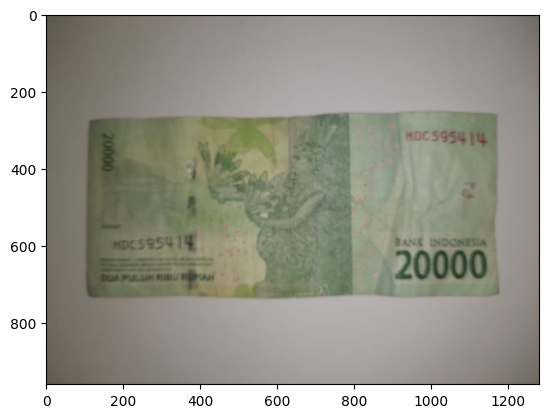

In [ ]:
ID_UJI =1

# Gunakan os.path.join untuk menggabungkan path
img_path = os.path.join(path_uji, file_uji[ID_UJI])
img_uji = plt.imread(img_path)

plt.imshow(img_uji)

# 4. Ekstraksi fitur gambar yang diuji

In [ ]:
feat_uji = create_features(img_uji)
print(feat_uji)

[139.6821541341146, 138.58711669921874, 125.45078125, 57.69348958333333]


# 5. Hitung jarak dari fitur gambar ke referensi

In [ ]:
import pandas as pd
import numpy as np
import re

hasil = []

# Pastikan semua list memiliki panjang yang sesuai
min_length = min(len(feat_referensi), len(file_uji), len(file_referensi))

for idx in range(min_length):
    try:
        jarak = np.linalg.norm(np.array(feat_uji) - np.array(feat_referensi[idx]))

        # Ekstrak nominal dari nama file dengan regex
        match_uji = re.search(r'(\d+)', file_uji[idx])  # Tangkap angka dari file_uji
        match_referensi = re.search(r'(\d+)', file_referensi[idx])  # Tangkap angka dari file_referensi

        if match_uji and match_referensi:
            nominal_ditanyakan = int(match_uji.group(1)) * 1000
            nominal_referensi = int(match_referensi.group(1)) * 1000

            temp = {
                "nominal_ditanyakan": nominal_ditanyakan,
                "nominal_referensi": nominal_referensi,
                "jarak": jarak,
            }
            hasil.append(temp)
        else:
            print(f"Kesalahan: Tidak dapat mengekstrak nominal dari {file_uji[idx]} atau {file_referensi[idx]}")
    except Exception as e:
        print(f"Kesalahan pemrosesan file: {file_uji[idx]} atau {file_referensi[idx]} - {e}")

# Buat DataFrame dari hasil jika ada data yang valid
if hasil:
    df_jarak = pd.DataFrame(hasil)
    print(df_jarak.head())
else:
    print("Tidak ada data yang valid untuk diproses.")


   nominal_ditanyakan  nominal_referensi       jarak
0               20000              20000  134.964677
1               20000              20000   87.212703
2               10000              10000  147.299833
3               10000               1000  131.339880
4                5000               5000  103.767893


# 6. Ambil k terdekat

In [ ]:
# sort by jarak dan ambil k terdekat
K_NEAREST = 5

df_k = df_jarak.sort_values(by=['jarak']).head(K_NEAREST)
df_k

,nominal_ditanyakan,nominal_referensi,jarak
1,20000,20000,87.212703
5,5000,5000,88.727248
4,5000,5000,103.767893
3,10000,1000,131.339880
0,20000,20000,134.964677


In [ ]:
# ambil nilai prediksi dari 5 nilai tadi
df_freq = df_k['nominal_referensi'].value_counts()
df_freq

,count
nominal_referensi,
20000,2
5000,2
1000,1


In [ ]:
print("Prediksi nilai nominal mata uang berdasarkan data referensi adalah: ")
print(df_freq.index[0])

Prediksi nilai nominal mata uang berdasarkan data referensi adalah: 
20000
